# Step 6 — Regional Aggregation Checkpoint

Verifies the `mhw-aggregate` output for GOA 2023:
1. Load `region_daily_goa.parquet`
2. Time series with event shading (area_frac > 0.05)
3. Scatter plot: Ibar vs Dbar coloured by area_frac
4. Verify conditional means are zero when area_frac = 0

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path("..")
parquet_path = ROOT / "data" / "derived" / "aggregates_region" / "region_daily_goa.parquet"

df = pd.read_parquet(parquet_path)
df["date"] = pd.to_datetime(df["date"])

print(f"Rows: {len(df)}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print()
print(df.describe().round(4))

Rows: 365
Date range: 2023-01-01 → 2023-12-31

                      date  area_frac      Ibar      Dbar      Cbar      Obar
count                  365   365.0000  365.0000  365.0000  365.0000  365.0000
mean   2023-07-02 00:00:00     0.0213    0.1476    7.2055    1.2765    0.0118
min    2023-01-01 00:00:00     0.0000    0.0000    0.0000    0.0000    0.0000
25%    2023-04-02 00:00:00     0.0000    0.0000    0.0000    0.0000    0.0000
50%    2023-07-02 00:00:00     0.0017    0.0478    6.6988    0.5070    0.0000
75%    2023-10-01 00:00:00     0.0208    0.2201   10.1829    1.7840    0.0103
max    2023-12-31 00:00:00     0.2263    2.1949   32.3319   25.6325    0.3311
std                    NaN     0.0415    0.2391    6.8795    2.0929    0.0304


## 1. Five-metric time series with event shading

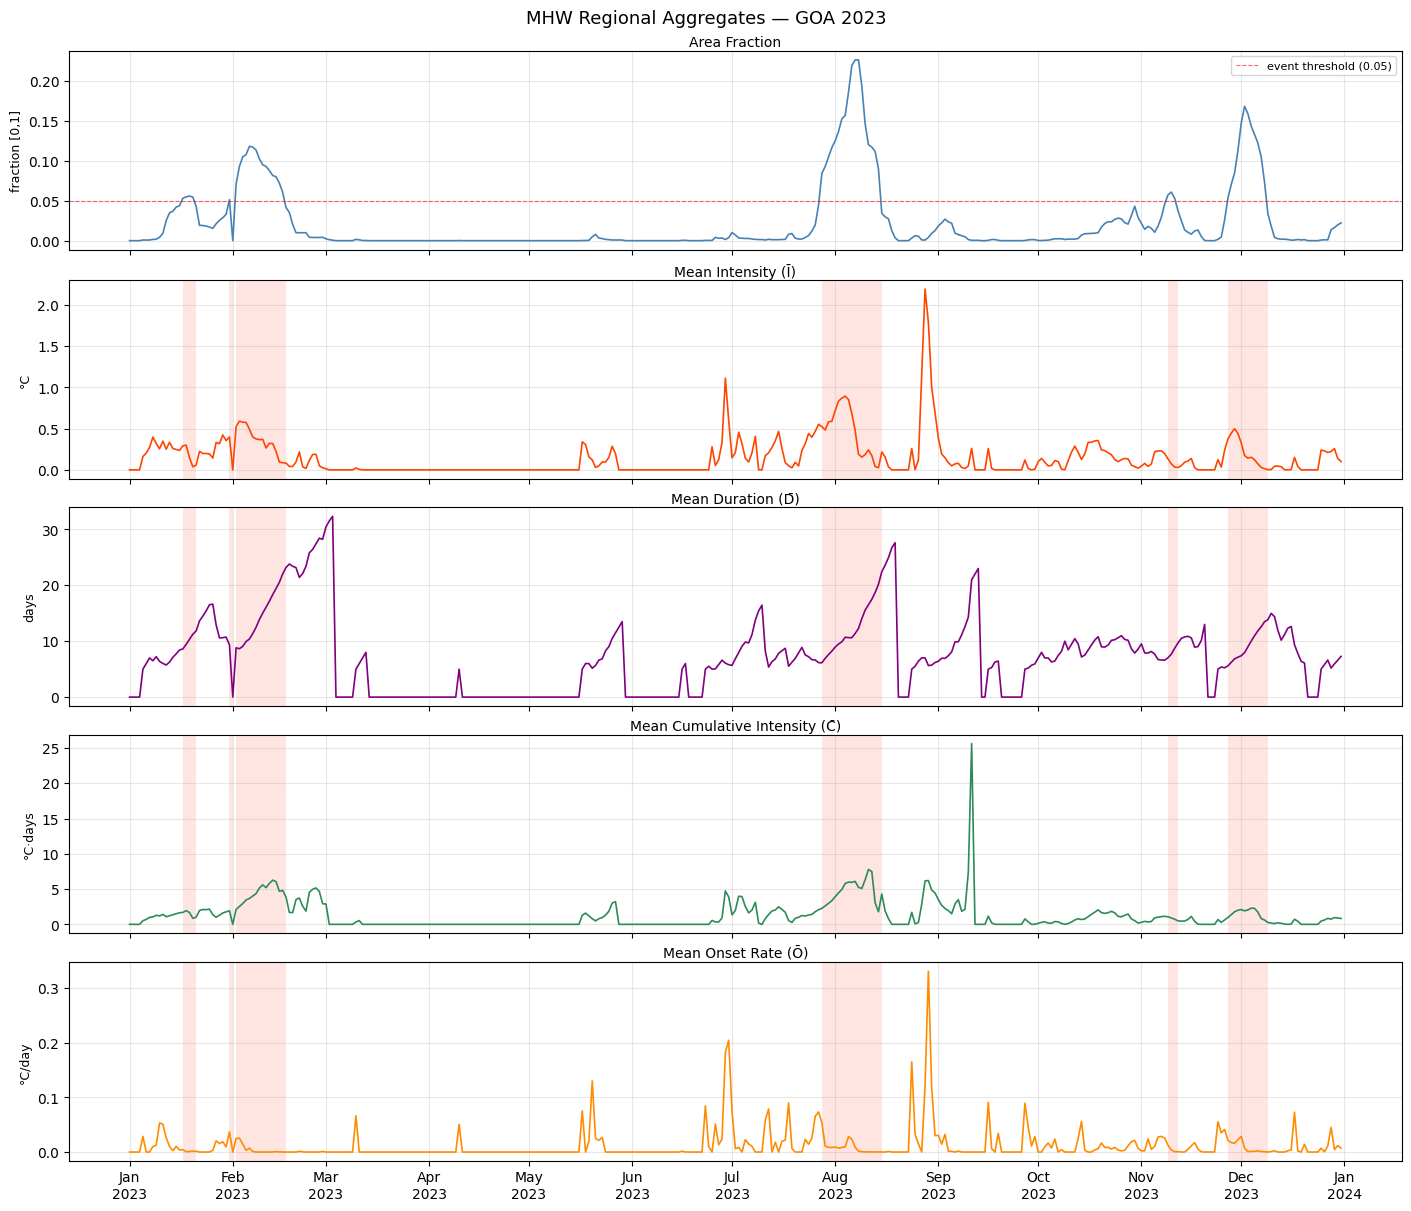

In [2]:
AREA_THRESH = 0.05   # regional event threshold from config

metrics = [
    ("area_frac", "Area Fraction",                  "fraction [0,1]", "steelblue"),
    ("Ibar",      "Mean Intensity (Ī)",             "°C",             "orangered"),
    ("Dbar",      "Mean Duration (D̄)",              "days",           "purple"),
    ("Cbar",      "Mean Cumulative Intensity (C̄)", "°C·days",        "seagreen"),
    ("Obar",      "Mean Onset Rate (Ō)",            "°C/day",         "darkorange"),
]

dates  = df["date"]
active = df["area_frac"].values > AREA_THRESH

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True, constrained_layout=True)
fig.suptitle("MHW Regional Aggregates — GOA 2023", fontsize=13)

for ax, (col, title, ylabel, color) in zip(axes, metrics):
    ax.plot(dates, df[col], color=color, linewidth=1.2)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, pad=3)
    ax.grid(True, alpha=0.3)

    if col != "area_frac":
        in_span = False
        for d, flag in zip(dates, active):
            if flag and not in_span:
                span_start = d
                in_span = True
            elif not flag and in_span:
                ax.axvspan(span_start, d, color="salmon", alpha=0.2, linewidth=0)
                in_span = False
        if in_span:
            ax.axvspan(span_start, dates.iloc[-1], color="salmon", alpha=0.2, linewidth=0)
    else:
        ax.axhline(AREA_THRESH, color="red", linestyle="--", linewidth=0.8, alpha=0.6,
                   label=f"event threshold ({AREA_THRESH})")
        ax.legend(fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.show()

## 2. Scatter: Ibar vs Dbar coloured by area_frac

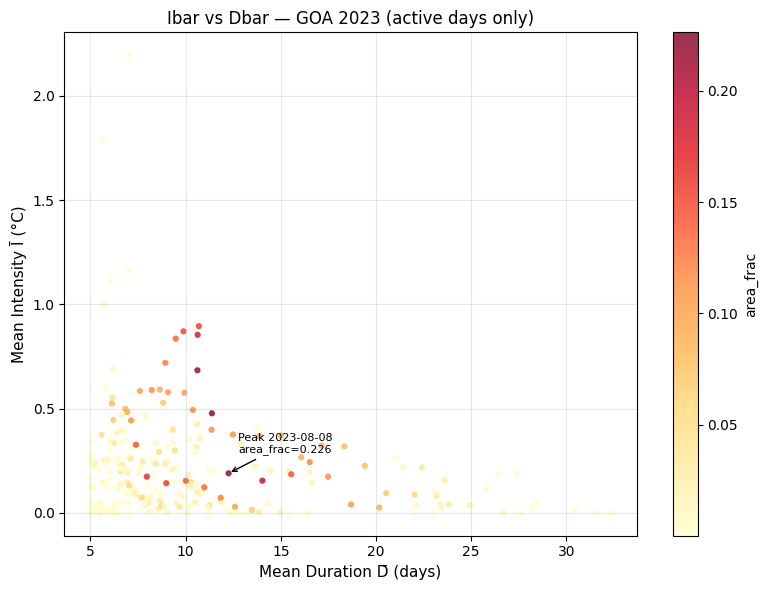

In [3]:
# Only plot days with at least some active area to avoid overplotting zeros
mask_pos = df["area_frac"] > 0

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    df.loc[mask_pos, "Dbar"],
    df.loc[mask_pos, "Ibar"],
    c=df.loc[mask_pos, "area_frac"],
    cmap="YlOrRd",
    s=20, alpha=0.8, edgecolors="none",
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("area_frac", fontsize=10)
ax.set_xlabel("Mean Duration D̄ (days)", fontsize=11)
ax.set_ylabel("Mean Intensity Ī (°C)", fontsize=11)
ax.set_title("Ibar vs Dbar — GOA 2023 (active days only)", fontsize=12)
ax.grid(True, alpha=0.3)

# Annotate peak area_frac day
peak_idx = df["area_frac"].idxmax()
peak = df.loc[peak_idx]
ax.annotate(
    f"Peak {peak['date'].strftime('%Y-%m-%d')}\narea_frac={peak['area_frac']:.3f}",
    xy=(peak["Dbar"], peak["Ibar"]),
    xytext=(peak["Dbar"] + 0.5, peak["Ibar"] + 0.1),
    fontsize=8,
    arrowprops={"arrowstyle": "->", "color": "black"},
)
plt.tight_layout()
plt.show()

## 3. Verify conditional means are zero when area_frac = 0

In [4]:
# When area_frac = 0, all conditional means must be exactly 0
inactive = df[df["area_frac"] == 0.0]
cond_vars = ["Ibar", "Dbar", "Cbar", "Obar"]

print(f"Inactive days (area_frac = 0): {len(inactive)}")
print()
print("Conditional means on inactive days (must all be 0):")
for col in cond_vars:
    vals = inactive[col].values
    max_abs = np.abs(vals).max()
    status = "OK" if max_abs == 0.0 else f"FAIL (max={max_abs:.6f})"
    print(f"  {col:8s}: max|val| = {max_abs:.6f}  [{status}]")

# Quick summary
print()
active_days = (df["area_frac"] > 0).sum()
event_days  = (df["area_frac"] > 0.05).sum()
print(f"Days with any active cells (area_frac > 0): {active_days}")
print(f"Regional event days        (area_frac > 0.05): {event_days}")
print(f"Inactive days              (area_frac = 0): {len(inactive)}")
print()
peak = df.loc[df["area_frac"].idxmax()]
print(f"Peak regional event:")
print(f"  date      = {peak['date'].strftime('%Y-%m-%d')}")
print(f"  area_frac = {peak['area_frac']:.4f}")
print(f"  Ibar      = {peak['Ibar']:.3f} °C")
print(f"  Dbar      = {peak['Dbar']:.1f} days")
print(f"  Cbar      = {peak['Cbar']:.2f} °C·days")
print(f"  Obar      = {peak['Obar']:.4f} °C/day")

Inactive days (area_frac = 0): 116

Conditional means on inactive days (must all be 0):
  Ibar    : max|val| = 0.000000  [OK]
  Dbar    : max|val| = 0.000000  [OK]
  Cbar    : max|val| = 0.000000  [OK]
  Obar    : max|val| = 0.000000  [OK]

Days with any active cells (area_frac > 0): 249
Regional event days        (area_frac > 0.05): 53
Inactive days              (area_frac = 0): 116

Peak regional event:
  date      = 2023-08-08
  area_frac = 0.2263
  Ibar      = 0.189 °C
  Dbar      = 12.3 days
  Cbar      = 5.24 °C·days
  Obar      = 0.0016 °C/day


## 4. Monthly summary table

In [5]:
df2 = df.copy()
df2["month"] = df2["date"].dt.month
monthly = df2.groupby("month").agg(
    event_days=("area_frac", lambda x: (x > 0.05).sum()),
    mean_area_frac=("area_frac", "mean"),
    max_area_frac=("area_frac", "max"),
    max_Ibar=("Ibar", "max"),
    max_Dbar=("Dbar", "max"),
).round(4)

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly.index = [month_names[i-1] for i in monthly.index]
print("Monthly summary — GOA 2023")
print(monthly.to_string())

Monthly summary — GOA 2023
     event_days  mean_area_frac  max_area_frac  max_Ibar   max_Dbar
Jan           5          0.0230         0.0559    0.4237  16.633600
Feb          15          0.0555         0.1181    0.5911  28.417700
Mar           0          0.0002         0.0023    0.0226  32.331902
Apr           0          0.0000         0.0002    0.0000   5.000000
May           0          0.0008         0.0078    0.3400  13.496900
Jun           0          0.0006         0.0042    1.1134   6.608200
Jul           4          0.0179         0.1165    0.5892  16.438700
Aug          14          0.0760         0.2263    2.1949  27.610500
Sep           0          0.0050         0.0269    0.3852  23.000000
Oct           0          0.0125         0.0432    0.3566  10.983900
Nov           7          0.0274         0.1125    0.4994  13.000000
Dec           8          0.0385         0.1681    0.3266  14.975700
